In [1]:
!pip install xgboost lightgbm imbalanced-learn
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import os, json
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 100

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import KNNImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, average_precision_score,
                              roc_curve, mean_squared_error, r2_score, mean_absolute_error)
from sklearn.linear_model import (LogisticRegression, SGDClassifier, LinearRegression,
                                   Ridge, Lasso, ElasticNet, BayesianRidge)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier, VotingClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from imblearn.over_sampling import SMOTE

print("="*70)
print("HEALTHCARE PREDICTIVE ANALYTICS — FULL ML PIPELINE v2")
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)

# Load
df = pd.read_excel('healthcare_predictive_dataset.xlsx')
print(f"\n[1] Dataset: {df.shape[0]} patients × {df.shape[1]} features")
os.makedirs('/home/claude/plots', exist_ok=True)


HEALTHCARE PREDICTIVE ANALYTICS — FULL ML PIPELINE v2
Started: 2026-05-23 14:32:47

[1] Dataset: 5000 patients × 74 features


In [2]:
# ── Feature Engineering ─────────────────────────────────────────────────────
print("\n[2] Feature Engineering...")
df['Metabolic_Syndrome_Score'] = (
    (df['Waist_Circumference_cm'] > 102).astype(int) +
    (df['Triglycerides_mg_dL'] >= 150).astype(int) +
    (df['HDL_Cholesterol_mg_dL'] < 40).astype(int) +
    (df['Systolic_BP'] >= 130).astype(int) +
    (df['Fasting_Glucose_mg_dL'] >= 100).astype(int))
df['Prediabetes_Flag'] = (
    ((df['Fasting_Glucose_mg_dL'] >= 100) & (df['Fasting_Glucose_mg_dL'] < 126)) |
    ((df['HbA1c_Pct'] >= 5.7) & (df['HbA1c_Pct'] < 6.5))).astype(int)
df['Insulin_Resistance_Flag'] = (df['HOMA_IR'] > 2.5).astype(int)
df['Hypertension_Stage'] = pd.cut(df['Systolic_BP'], bins=[0,120,130,140,180,300], labels=[0,1,2,3,4]).astype(float)
df['Obesity_Class'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,35,40,100], labels=[0,1,2,3,4,5]).astype(float)
df['Cardiovascular_Load'] = df['Systolic_BP'] * df['Resting_Heart_Rate'] / 100
df['Lipid_Triad_Risk'] = ((df['LDL_Cholesterol_mg_dL']>130).astype(int) +
                           (df['Triglycerides_mg_dL']>200).astype(int) +
                           (df['HDL_Cholesterol_mg_dL']<40).astype(int))
df['Inflammation_Score'] = np.log1p(df['CRP_mg_L']) * df['WBC_Count_K_uL']
df['Lifestyle_Risk_Score'] = (
    (df['Physical_Activity_Min_Week'] < 150).astype(int)*2 +
    (df['Sedentary_Hours_Day'] > 8).astype(int) +
    (df['Sleep_Hours_Night'] < 6).astype(int) +
    (df['Diet_Quality_Score'] < 40).astype(int) +
    (df['Stress_Score'] > 70).astype(int))
df['Family_Risk_Burden'] = (df['Family_Hx_Diabetes'] + df['Family_Hx_Heart_Disease'] +
                             df['Family_Hx_Hypertension'] + df['Family_Hx_Stroke'])
df['Age_BMI_Interaction'] = df['Age'] * df['BMI'] / 100
df['Age_Glucose_Interaction'] = df['Age'] * df['Fasting_Glucose_mg_dL'] / 1000
df['Log_CRP'] = np.log1p(df['CRP_mg_L'])
df['Log_Triglycerides'] = np.log1p(df['Triglycerides_mg_dL'])
df['Log_Insulin'] = np.log1p(df['Fasting_Insulin_uIU_mL'])
df['Renal_Metabolic_Index'] = df['Creatinine_mg_dL'] * df['Uric_Acid_mg_dL']
print(f"   Total features after engineering: {df.shape[1]}")



[2] Feature Engineering...
   Total features after engineering: 90


In [3]:
# ── Prepare Features ─────────────────────────────────────────────────────────
drop_cols = ['Patient_ID', 'Exam_Date', 'Diabetes_Risk', 'Heart_Disease_Risk', 'Overall_Risk_Category']
feature_cols = [c for c in df.columns if c not in drop_cols]
cat_cols = ['Gender', 'Ethnicity', 'Region', 'Education_Level', 'Income_Bracket', 'Insurance_Type', 'Smoking_Status']

X = df[feature_cols].copy()
for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
X = X.values.astype(float)
y_diab = df['Diabetes_Risk'].values
y_heart = df['Heart_Disease_Risk'].values

# Splits — same indices for both targets
X_tr_raw, X_te_raw, yd_tr, yd_te, yh_tr, yh_te = train_test_split(
    X, y_diab, y_heart, test_size=0.2, random_state=42, stratify=y_diab)

# Impute
imp = KNNImputer(n_neighbors=5)
X_tr = imp.fit_transform(X_tr_raw)
X_te = imp.transform(X_te_raw)

# Scale
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

# SMOTE per target
sm = SMOTE(random_state=42)
X_tr_d, yd_tr_sm = sm.fit_resample(X_tr_s, yd_tr)
X_tr_h, yh_tr_sm = sm.fit_resample(X_tr_s, yh_tr)

print(f"\n[3] Preprocessing complete")
print(f"   Train: {X_tr.shape[0]} | Test: {X_te.shape[0]}")
print(f"   After SMOTE Diabetes: {np.bincount(yd_tr_sm)}")
print(f"   After SMOTE Heart: {np.bincount(yh_tr_sm)}")




[3] Preprocessing complete
   Train: 4000 | Test: 1000
   After SMOTE Diabetes: [3562 3562]
   After SMOTE Heart: [3331 3331]


In [4]:
# ── Classifiers ──────────────────────────────────────────────────────────────
def eval_clf(mdl, X_tr, y_tr, X_te, y_te, name):
    mdl.fit(X_tr, y_tr)
    yp = mdl.predict(X_te)
    prob = mdl.predict_proba(X_te)[:,1] if hasattr(mdl,'predict_proba') else mdl.decision_function(X_te)
    return {
        'Model': name,
        'Accuracy': round(accuracy_score(y_te,yp)*100,2),
        'Precision': round(precision_score(y_te,yp,zero_division=0)*100,2),
        'Recall': round(recall_score(y_te,yp,zero_division=0)*100,2),
        'F1_Score': round(f1_score(y_te,yp,zero_division=0)*100,2),
        'ROC_AUC': round(roc_auc_score(y_te,prob)*100,2),
        'Avg_Precision': round(average_precision_score(y_te,prob)*100,2),
    }, mdl

CLF_SPECS = [
    ('Logistic Regression',  LogisticRegression(max_iter=1000, C=0.5, random_state=42)),
    ('LDA',                  LinearDiscriminantAnalysis()),
    ('QDA',                  QuadraticDiscriminantAnalysis(reg_param=0.1)),
    ('Decision Tree',        DecisionTreeClassifier(max_depth=8, min_samples_split=20, random_state=42)),
    ('Random Forest',        RandomForestClassifier(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1)),
    ('Extra Trees',          ExtraTreesClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',    GradientBoostingClassifier(n_estimators=200, learning_rate=0.08, max_depth=5, random_state=42)),
    ('XGBoost',              XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0, eval_metric='logloss')),
    ('LightGBM',             LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42, verbose=-1)),
    ('AdaBoost',             AdaBoostClassifier(n_estimators=150, learning_rate=0.5, random_state=42)),
    ('SVM (RBF)',            SVC(kernel='rbf', probability=True, C=1.0, random_state=42)),
    ('KNN (k=7)',            KNeighborsClassifier(n_neighbors=7, weights='distance', n_jobs=-1)),
    ('Naive Bayes',          GaussianNB()),
    ('MLP Neural Net',       MLPClassifier(hidden_layer_sizes=(128,64,32), max_iter=500, random_state=42,
                                            early_stopping=True, validation_fraction=0.1)),
    ('SGD Classifier',       SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)),
]

print("\n[4] Training Classification Models — DIABETES RISK...")
d_results, d_models = [], {}
for name, clf in CLF_SPECS:
    try:
        res, trained = eval_clf(clf, X_tr_d, yd_tr_sm, X_te_s, yd_te, name)
        d_results.append(res); d_models[name] = trained
        print(f"   ✓ {name:<25} AUC={res['ROC_AUC']:.1f}%  F1={res['F1_Score']:.1f}%  Acc={res['Accuracy']:.1f}%")
    except Exception as e:
        print(f"   ✗ {name}: {e}")

df_d = pd.DataFrame(d_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_d.index += 1

print("\n[5] Training Classification Models — HEART DISEASE RISK...")
h_results, h_models = [], {}
for name, clf in CLF_SPECS:
    try:
        clf2 = clf.__class__(**clf.get_params())
        res, trained = eval_clf(clf2, X_tr_h, yh_tr_sm, X_te_s, yh_te, name)
        h_results.append(res); h_models[name] = trained
        print(f"   ✓ {name:<25} AUC={res['ROC_AUC']:.1f}%  F1={res['F1_Score']:.1f}%  Acc={res['Accuracy']:.1f}%")
    except Exception as e:
        print(f"   ✗ {name}: {e}")

df_h = pd.DataFrame(h_results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
df_h.index += 1




[4] Training Classification Models — DIABETES RISK...
   ✓ Logistic Regression       AUC=83.5%  F1=39.5%  Acc=76.4%
   ✓ LDA                       AUC=83.3%  F1=38.1%  Acc=74.3%
   ✓ QDA                       AUC=70.8%  F1=27.4%  Acc=83.6%
   ✓ Decision Tree             AUC=72.6%  F1=32.6%  Acc=81.0%
   ✓ Random Forest             AUC=81.6%  F1=31.5%  Acc=86.5%
   ✓ Extra Trees               AUC=82.2%  F1=10.3%  Acc=87.8%
   ✓ Gradient Boosting         AUC=80.9%  F1=32.3%  Acc=88.7%
   ✓ XGBoost                   AUC=81.9%  F1=25.6%  Acc=88.4%
   ✓ LightGBM                  AUC=82.1%  F1=20.6%  Acc=88.4%
   ✓ AdaBoost                  AUC=83.1%  F1=38.5%  Acc=85.6%
   ✓ SVM (RBF)                 AUC=80.2%  F1=29.9%  Acc=86.4%
   ✓ KNN (k=7)                 AUC=74.1%  F1=27.3%  Acc=44.6%
   ✓ Naive Bayes               AUC=76.6%  F1=33.5%  Acc=73.8%
   ✓ MLP Neural Net            AUC=82.1%  F1=34.2%  Acc=85.4%
   ✓ SGD Classifier            AUC=82.6%  F1=39.3%  Acc=75.3%

[5] Training C

In [5]:
# ── Regression ───────────────────────────────────────────────────────────────
print("\n[6] Regression Models — Cardio Risk Score...")
y_reg = df['Cardio_Risk_Score'].values
idx = np.arange(len(df))
itr, ite = train_test_split(idx, test_size=0.2, random_state=42, stratify=y_diab)
yr_tr = y_reg[itr]; yr_te = y_reg[ite]

REGS = [
    ('Linear Regression',   LinearRegression()),
    ('Ridge (α=1)',          Ridge(alpha=1.0)),
    ('Lasso (α=0.01)',       Lasso(alpha=0.01)),
    ('ElasticNet',           ElasticNet(alpha=0.01, l1_ratio=0.5)),
    ('Bayesian Ridge',       BayesianRidge()),
    ('Random Forest Reg',   RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ('Gradient Boost Reg',  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42)),
    ('XGBoost Reg',         XGBRegressor(n_estimators=200, learning_rate=0.05, verbosity=0, random_state=42)),
    ('LightGBM Reg',        LGBMRegressor(n_estimators=200, learning_rate=0.05, verbose=-1, random_state=42)),
]

reg_results = []
reg_models = {}
for name, reg in REGS:
    try:
        reg.fit(X_tr_s, yr_tr)
        yp = reg.predict(X_te_s)
        rmse = np.sqrt(mean_squared_error(yr_te, yp))
        mae = mean_absolute_error(yr_te, yp)
        r2 = r2_score(yr_te, yp)
        reg_results.append({'Model':name,'RMSE':round(rmse,4),'MAE':round(mae,4),'R2':round(r2,4)})
        reg_models[name] = reg
        print(f"   ✓ {name:<22} RMSE={rmse:.4f}  R²={r2:.4f}")
    except Exception as e:
        print(f"   ✗ {name}: {e}")

df_reg = pd.DataFrame(reg_results).sort_values('R2', ascending=False).reset_index(drop=True)
df_reg.index += 1

# ── Cross-Validation ──────────────────────────────────────────────────────────
print("\n[7] 5-Fold Stratified Cross-Validation...")
top_cv = {
    'XGBoost': XGBClassifier(n_estimators=200, learning_rate=0.06, max_depth=6, random_state=42, verbosity=0, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=200, learning_rate=0.06, random_state=42, verbose=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, C=0.5, random_state=42),
}
cv_obj = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_res = {}
for name, mdl in top_cv.items():
    scores = cross_val_score(mdl, X_tr_d, yd_tr_sm, cv=cv_obj, scoring='roc_auc', n_jobs=-1)
    cv_res[name] = {'mean': round(scores.mean()*100,2), 'std': round(scores.std()*100,2)}
    print(f"   {name:<22} AUC = {scores.mean()*100:.2f}% ± {scores.std()*100:.2f}%")




[6] Regression Models — Cardio Risk Score...
   ✓ Linear Regression      RMSE=0.0000  R²=1.0000
   ✓ Ridge (α=1)            RMSE=0.0006  R²=1.0000
   ✓ Lasso (α=0.01)         RMSE=0.0097  R²=0.9999
   ✓ ElasticNet             RMSE=0.0091  R²=0.9999
   ✓ Bayesian Ridge         RMSE=0.0000  R²=1.0000
   ✓ Random Forest Reg      RMSE=0.0038  R²=1.0000
   ✓ Gradient Boost Reg     RMSE=0.0034  R²=1.0000
   ✓ XGBoost Reg            RMSE=0.0192  R²=0.9994
   ✓ LightGBM Reg           RMSE=0.0281  R²=0.9988

[7] 5-Fold Stratified Cross-Validation...
   XGBoost                AUC = 98.89% ± 0.10%
   LightGBM               AUC = 98.87% ± 0.10%
   Random Forest          AUC = 99.41% ± 0.07%
   Gradient Boosting      AUC = 98.57% ± 0.15%
   Logistic Regression    AUC = 87.82% ± 0.55%


In [6]:
# ── Hyperparameter Tuning ─────────────────────────────────────────────────────
print("\n[8] GridSearchCV — XGBoost Hyperparameter Tuning...")
param_grid = {'n_estimators':[200,300], 'max_depth':[5,6,7], 'learning_rate':[0.04,0.07], 'subsample':[0.8,1.0]}
xgb_gs = GridSearchCV(XGBClassifier(verbosity=0, eval_metric='logloss', random_state=42),
                       param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
xgb_gs.fit(X_tr_d, yd_tr_sm)
best_xgb = xgb_gs.best_estimator_
tuned_auc = roc_auc_score(yd_te, best_xgb.predict_proba(X_te_s)[:,1])*100
print(f"   Best params: {xgb_gs.best_params_}")
print(f"   Tuned XGBoost AUC: {tuned_auc:.2f}%")



[8] GridSearchCV — XGBoost Hyperparameter Tuning...
   Best params: {'learning_rate': 0.04, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
   Tuned XGBoost AUC: 81.91%


In [7]:
# ── Voting Ensemble ────────────────────────────────────────────────────────────
print("\n[9] Soft Voting Ensemble...")
voter = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(n_estimators=200, learning_rate=0.06, max_depth=6, verbosity=0, eval_metric='logloss', random_state=42)),
    ('lgbm', LGBMClassifier(n_estimators=200, learning_rate=0.06, verbose=-1, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=150, learning_rate=0.08, max_depth=5, random_state=42)),
], voting='soft', n_jobs=-1)
voter.fit(X_tr_d, yd_tr_sm)
ens_auc = roc_auc_score(yd_te, voter.predict_proba(X_te_s)[:,1])*100
ens_f1  = f1_score(yd_te, voter.predict(X_te_s))*100
print(f"   Ensemble AUC: {ens_auc:.2f}%  F1: {ens_f1:.2f}%")


[9] Soft Voting Ensemble...
   Ensemble AUC: 82.38%  F1: 24.16%


In [8]:
# ── Feature Importance ────────────────────────────────────────────────────────
print("\n[10] Feature Importance...")
fi_xgb  = pd.DataFrame({'Feature': feature_cols, 'XGBoost': best_xgb.feature_importances_}).sort_values('XGBoost', ascending=False).head(20)
rf_mdl = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1).fit(X_tr_d, yd_tr_sm)
fi_rf   = pd.DataFrame({'Feature': feature_cols, 'RandomForest': rf_mdl.feature_importances_}).sort_values('RandomForest', ascending=False).head(20)
lgbm_mdl = LGBMClassifier(n_estimators=200, verbose=-1, random_state=42).fit(X_tr_d, yd_tr_sm)
fi_lgbm = pd.DataFrame({'Feature': feature_cols, 'LightGBM': lgbm_mdl.feature_importances_}).sort_values('LightGBM', ascending=False).head(20)


[10] Feature Importance...


In [9]:
# ── Scaler Comparison ─────────────────────────────────────────────────────────
print("\n[11] Scaler Comparison...")
scaler_res = {}
for sc_name, sc_obj in [('StandardScaler',StandardScaler()),('MinMaxScaler',MinMaxScaler()),('RobustScaler',RobustScaler())]:
    Xts = sc_obj.fit_transform(X_tr); Xtes = sc_obj.transform(X_te)
    Xsm, ysm = SMOTE(random_state=42).fit_resample(Xts, yd_tr)
    m = LGBMClassifier(n_estimators=100, verbose=-1, random_state=42).fit(Xsm, ysm)
    auc = roc_auc_score(yd_te, m.predict_proba(Xtes)[:,1])*100
    scaler_res[sc_name] = round(auc,2)
    print(f"   {sc_name}: AUC = {auc:.2f}%")


[11] Scaler Comparison...
   StandardScaler: AUC = 82.01%
   MinMaxScaler: AUC = 82.58%
   RobustScaler: AUC = 81.12%



[12] Generating Plots...


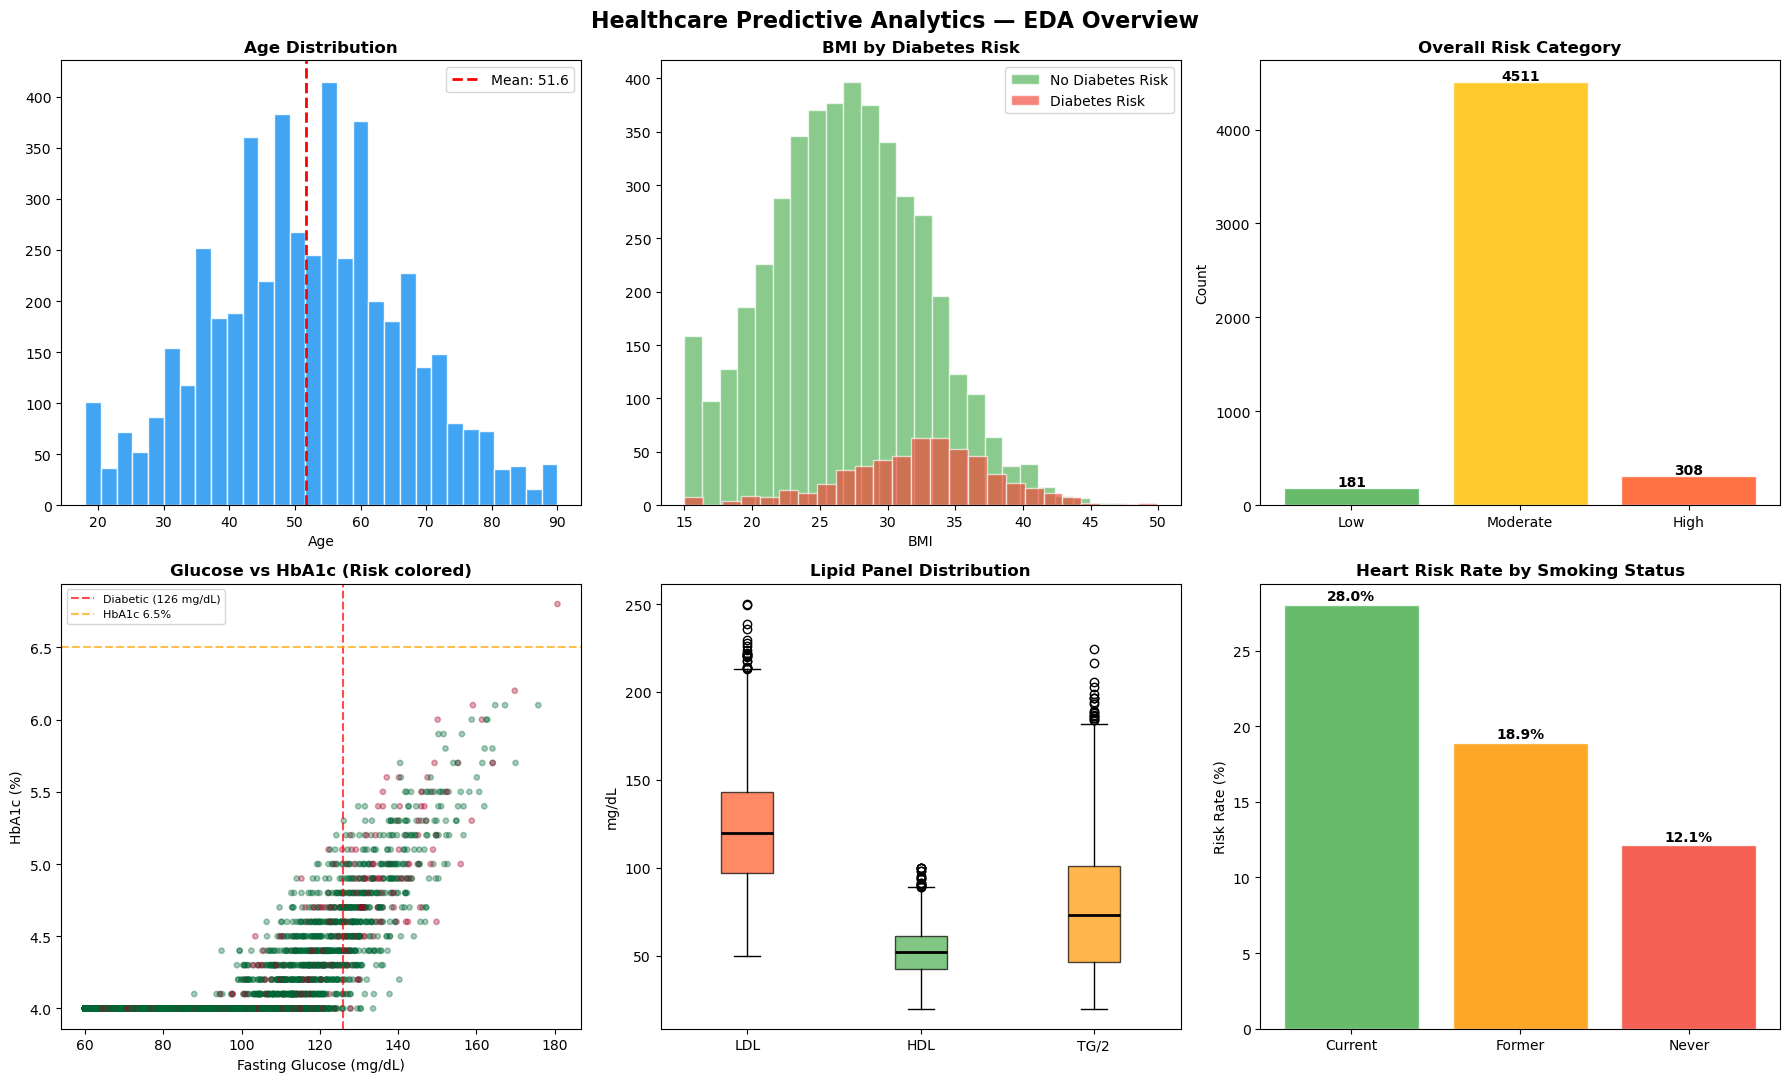

In [10]:

# ══════════════════════════════════════════════════════════════════════════════
# PLOTS
# ══════════════════════════════════════════════════════════════════════════════
print("\n[12] Generating Plots...")

# ── Plot 1: EDA Overview ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(18,11))
fig.suptitle('Healthcare Predictive Analytics — EDA Overview', fontsize=16, fontweight='bold')

axes[0,0].hist(df['Age'], bins=30, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['Age'].mean(), color='red', linestyle='--', lw=2, label=f'Mean: {df["Age"].mean():.1f}')
axes[0,0].set_title('Age Distribution', fontweight='bold'); axes[0,0].set_xlabel('Age'); axes[0,0].legend()

for v, lbl, c in [(0,'No Diabetes Risk','#4CAF50'),(1,'Diabetes Risk','#F44336')]:
    axes[0,1].hist(df[df['Diabetes_Risk']==v]['BMI'], bins=25, alpha=0.65, color=c, label=lbl, edgecolor='white')
axes[0,1].set_title('BMI by Diabetes Risk', fontweight='bold'); axes[0,1].set_xlabel('BMI'); axes[0,1].legend()

cats = ['Low','Moderate','High']; rc = df['Overall_Risk_Category'].value_counts().reindex(cats, fill_value=0)
axes[0,2].bar(rc.index, rc.values, color=['#4CAF50','#FFC107','#FF5722'], alpha=0.85, edgecolor='white')
axes[0,2].set_title('Overall Risk Category', fontweight='bold'); axes[0,2].set_ylabel('Count')
for i,(k,v) in enumerate(rc.items()): axes[0,2].text(i, v+20, str(v), ha='center', fontweight='bold')

sc2 = axes[1,0].scatter(df['Fasting_Glucose_mg_dL'], df['HbA1c_Pct'], c=df['Diabetes_Risk'], cmap='RdYlGn_r', alpha=0.35, s=15)
axes[1,0].axvline(126, color='red', linestyle='--', alpha=0.7, label='Diabetic (126 mg/dL)')
axes[1,0].axhline(6.5, color='orange', linestyle='--', alpha=0.7, label='HbA1c 6.5%')
axes[1,0].set_title('Glucose vs HbA1c (Risk colored)', fontweight='bold')
axes[1,0].set_xlabel('Fasting Glucose (mg/dL)'); axes[1,0].set_ylabel('HbA1c (%)'); axes[1,0].legend(fontsize=8)

bp = axes[1,1].boxplot([df['LDL_Cholesterol_mg_dL'], df['HDL_Cholesterol_mg_dL'], df['Triglycerides_mg_dL']/2],
                        labels=['LDL','HDL','TG/2'], patch_artist=True,
                        medianprops={'color':'black','linewidth':2})
for patch, c in zip(bp['boxes'],['#FF5722','#4CAF50','#FF9800']): patch.set_facecolor(c); patch.set_alpha(0.7)
axes[1,1].set_title('Lipid Panel Distribution', fontweight='bold'); axes[1,1].set_ylabel('mg/dL')

smoke_risk = df.groupby('Smoking_Status')['Heart_Disease_Risk'].mean()*100
axes[1,2].bar(smoke_risk.index, smoke_risk.values, color=['#4CAF50','#FF9800','#F44336'], alpha=0.85, edgecolor='white')
axes[1,2].set_title('Heart Risk Rate by Smoking Status', fontweight='bold'); axes[1,2].set_ylabel('Risk Rate (%)')
for i,v in enumerate(smoke_risk.values): axes[1,2].text(i, v+0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout();
plt.savefig('/home/claude/plots/01_eda_overview.png', dpi=150, bbox_inches='tight');
plt.show()

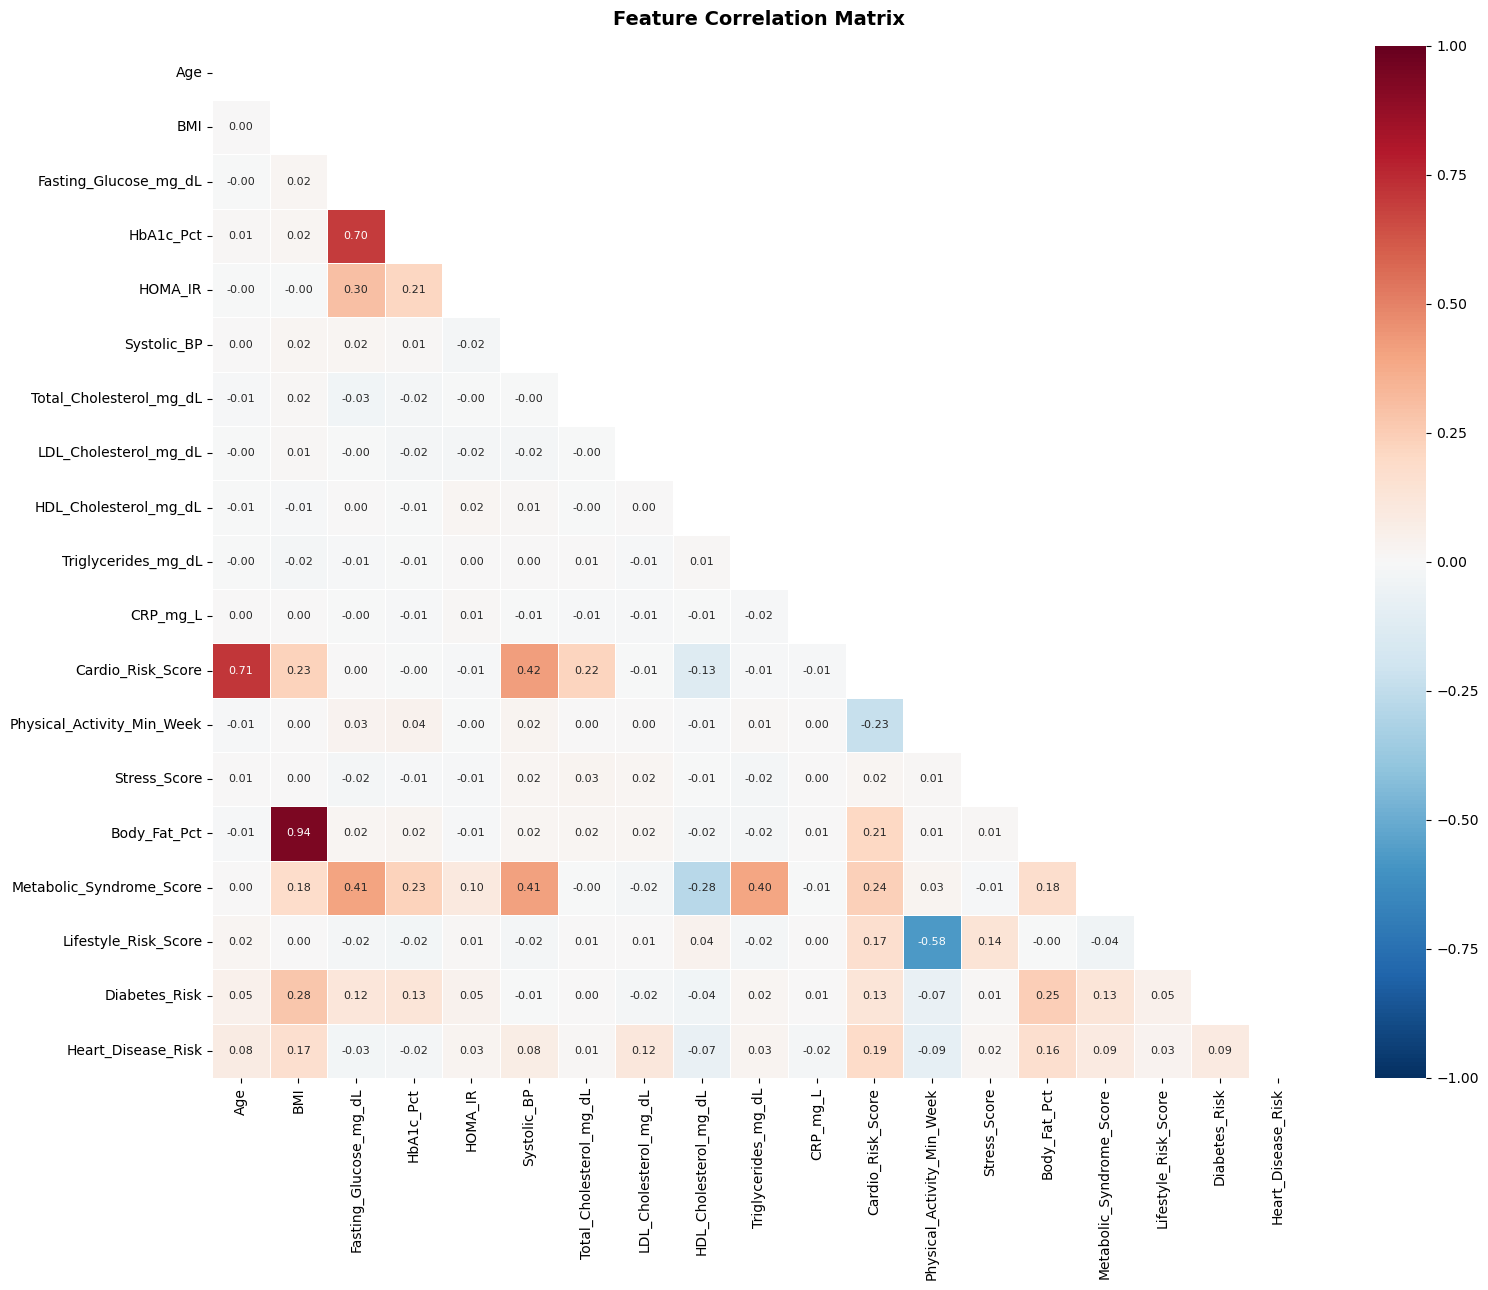

In [11]:
# ── Plot 2: Correlation Heatmap ───────────────────────────────────────────────
key = ['Age','BMI','Fasting_Glucose_mg_dL','HbA1c_Pct','HOMA_IR','Systolic_BP',
       'Total_Cholesterol_mg_dL','LDL_Cholesterol_mg_dL','HDL_Cholesterol_mg_dL',
       'Triglycerides_mg_dL','CRP_mg_L','Cardio_Risk_Score','Physical_Activity_Min_Week',
       'Stress_Score','Body_Fat_Pct','Metabolic_Syndrome_Score','Lifestyle_Risk_Score',
       'Diabetes_Risk','Heart_Disease_Risk']
corr = df[key].corr()
fig, ax = plt.subplots(figsize=(16,13))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size':8}, vmin=-1, vmax=1,
            mask=np.triu(np.ones_like(corr, dtype=bool)))
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout(); plt.savefig('/home/claude/plots/02_correlation_heatmap.png', dpi=150, bbox_inches='tight');
plt.show()

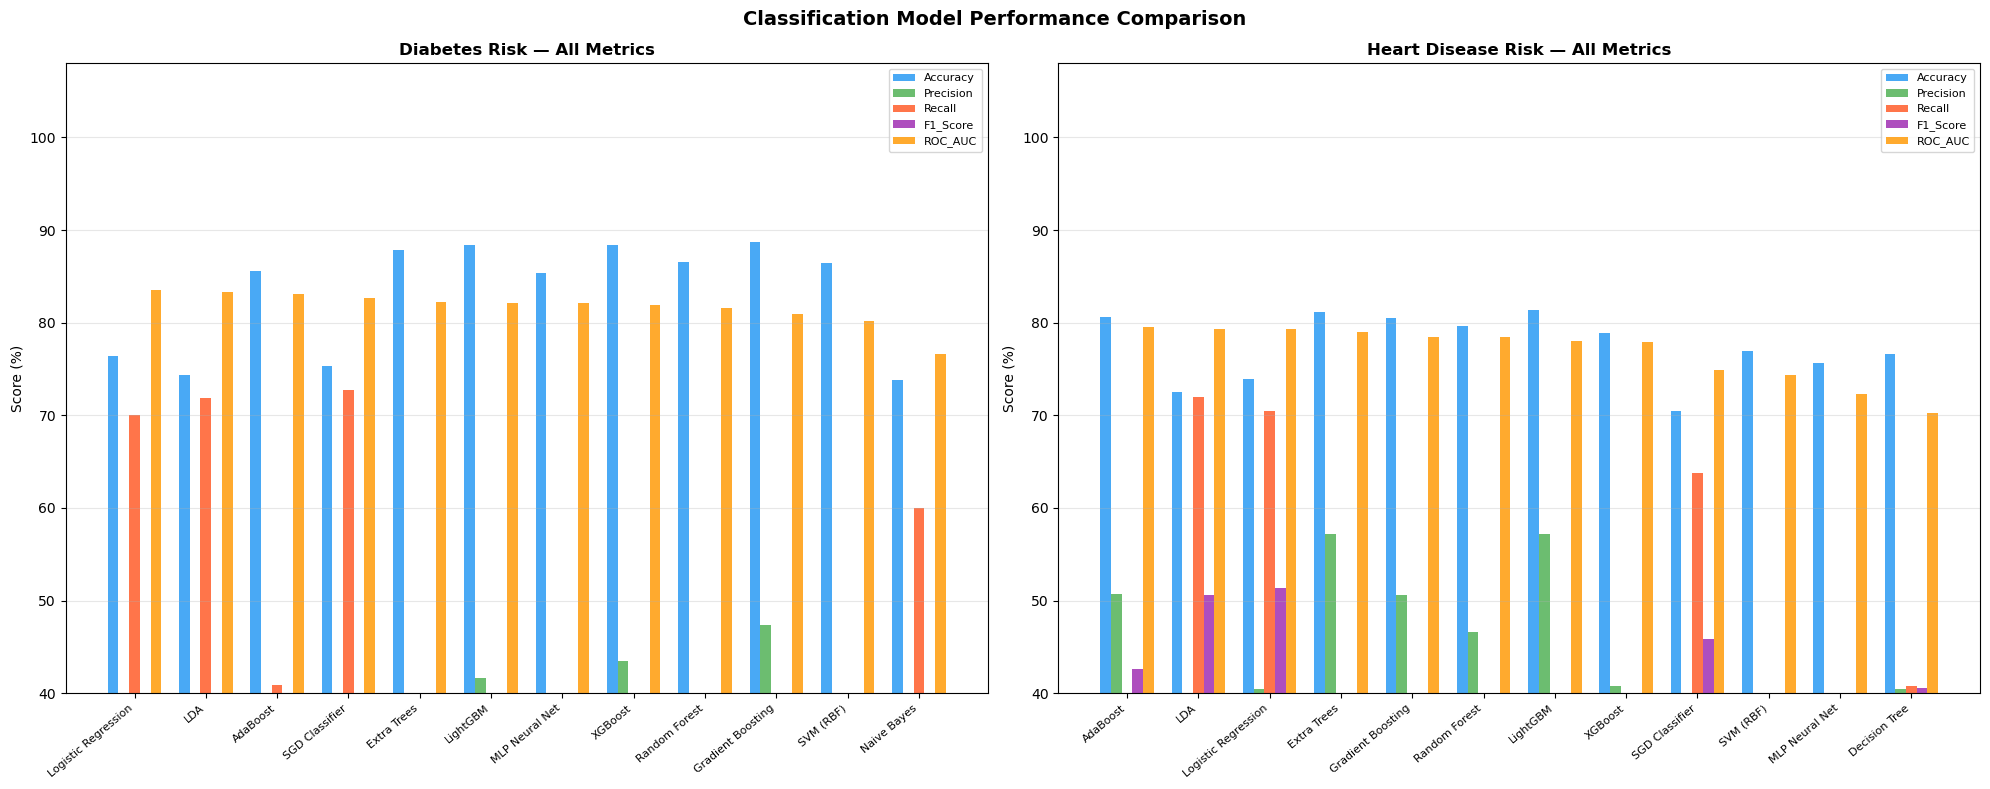

In [12]:
# ── Plot 3: Model Comparison ──────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(20,8))
fig.suptitle('Classification Model Performance Comparison', fontsize=14, fontweight='bold')
metrics = ['Accuracy','Precision','Recall','F1_Score','ROC_AUC']
colors_m = ['#2196F3','#4CAF50','#FF5722','#9C27B0','#FF9800']
width = 0.15
for ax_i, (df_res, title) in enumerate([(df_d,'Diabetes Risk'),(df_h,'Heart Disease Risk')]):
    top = df_res.head(12)
    x = np.arange(len(top))
    for i,(m,c) in enumerate(zip(metrics,colors_m)):
        axes[ax_i].bar(x+i*width, top[m], width, label=m, color=c, alpha=0.82)
    axes[ax_i].set_xticks(x+width*2); axes[ax_i].set_xticklabels(top['Model'], rotation=40, ha='right', fontsize=8)
    axes[ax_i].set_title(f'{title} — All Metrics', fontweight='bold')
    axes[ax_i].set_ylabel('Score (%)'); axes[ax_i].set_ylim(40,108)
    axes[ax_i].legend(fontsize=8); axes[ax_i].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('/home/claude/plots/03_model_comparison.png', dpi=150, bbox_inches='tight');
plt.show()

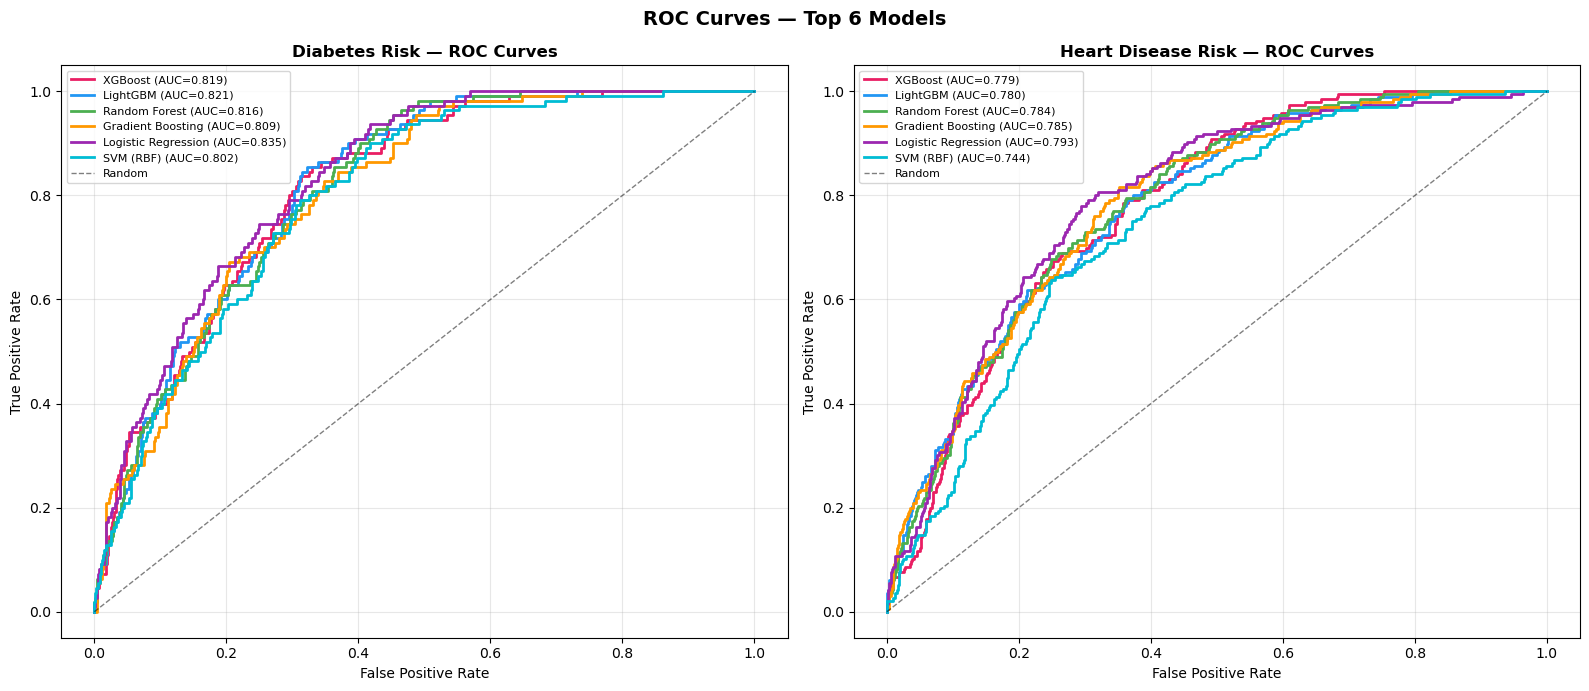

In [13]:
# ── Plot 4: ROC Curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,7))
fig.suptitle('ROC Curves — Top 6 Models', fontsize=14, fontweight='bold')
top_names = ['XGBoost','LightGBM','Random Forest','Gradient Boosting','Logistic Regression','SVM (RBF)']
roc_colors = ['#E91E63','#2196F3','#4CAF50','#FF9800','#9C27B0','#00BCD4']

for ax_i, (models_d, y_te, title) in enumerate([(d_models,yd_te,'Diabetes'), (h_models,yh_te,'Heart Disease')]):
    for i, nm in enumerate(top_names):
        if nm in models_d:
            pr = models_d[nm].predict_proba(X_te_s)[:,1]
            fpr, tpr, _ = roc_curve(y_te, pr)
            auc = roc_auc_score(y_te, pr)
            axes[ax_i].plot(fpr, tpr, label=f'{nm} (AUC={auc:.3f})', color=roc_colors[i], lw=2)
    axes[ax_i].plot([0,1],[0,1],'k--',lw=1,alpha=0.5,label='Random')
    axes[ax_i].set_xlabel('False Positive Rate'); axes[ax_i].set_ylabel('True Positive Rate')
    axes[ax_i].set_title(f'{title} Risk — ROC Curves', fontweight='bold')
    axes[ax_i].legend(fontsize=8); axes[ax_i].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('/home/claude/plots/04_roc_curves.png', dpi=150, bbox_inches='tight');
plt.show()

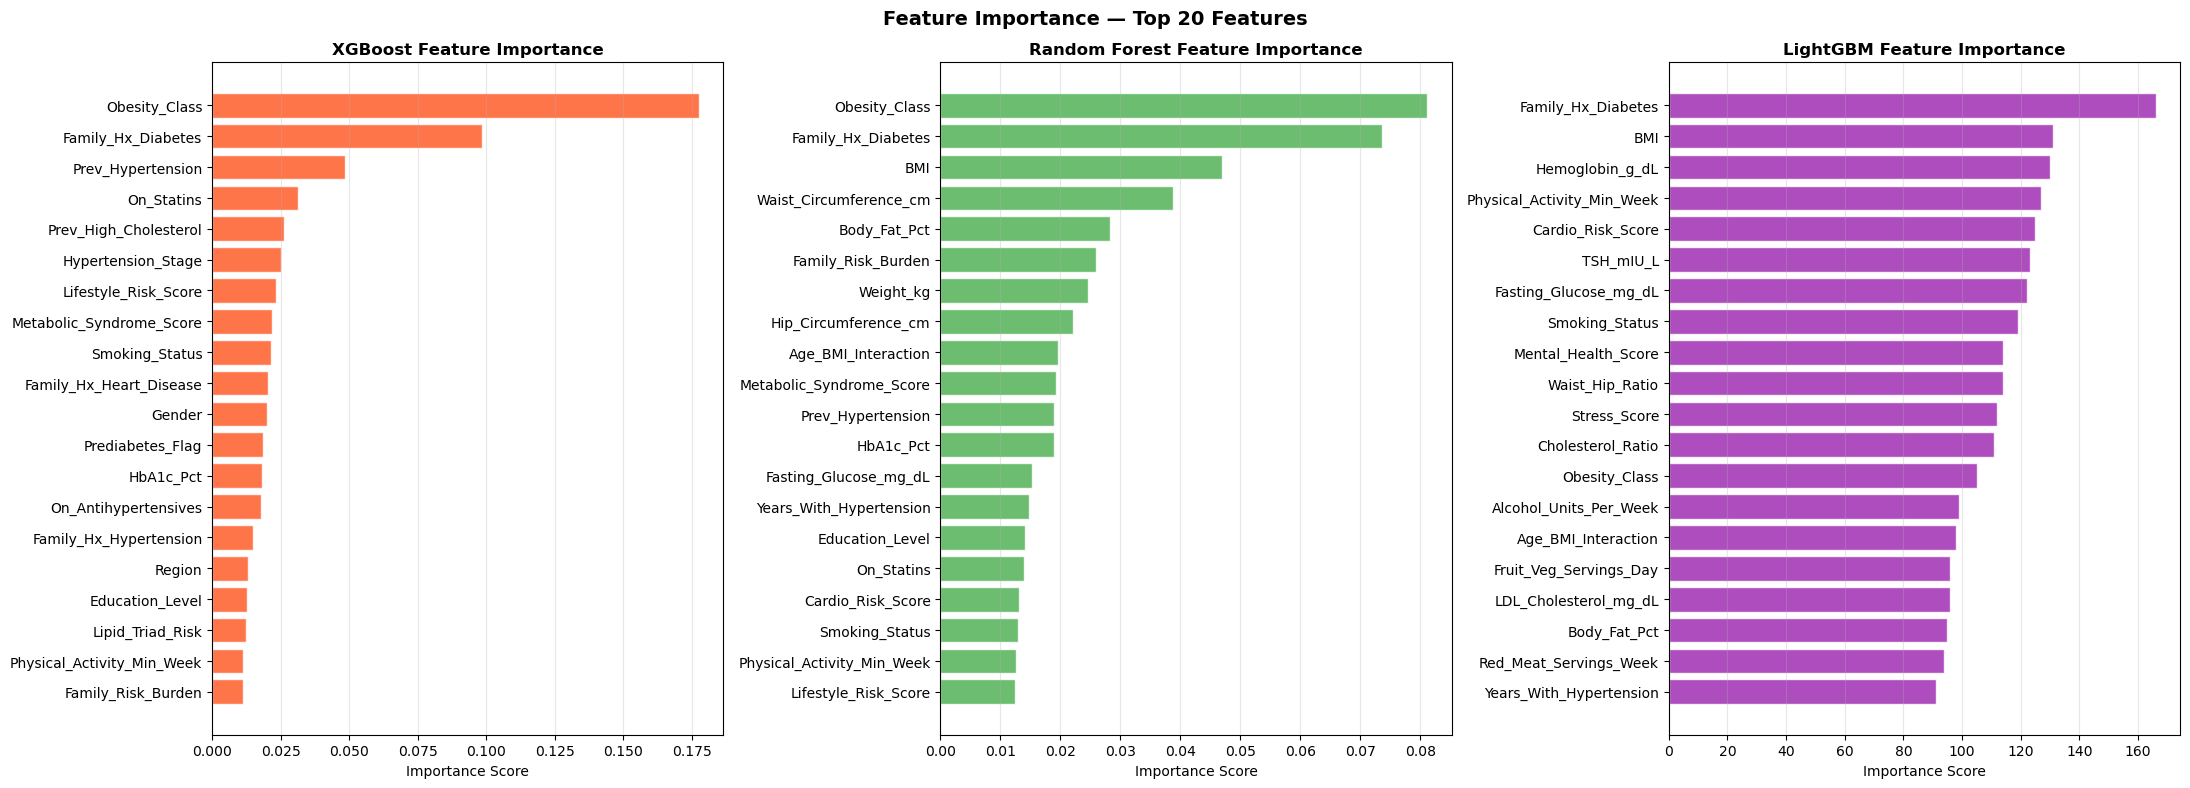

In [14]:
# ── Plot 5: Feature Importance ────────────────────────────────────────────────
fig, axes = plt.subplots(1,3,figsize=(22,8))
fig.suptitle('Feature Importance — Top 20 Features', fontsize=14, fontweight='bold')
for ax, fi_df, col, title, color in [
    (axes[0], fi_xgb, 'XGBoost', 'XGBoost', '#FF5722'),
    (axes[1], fi_rf,  'RandomForest', 'Random Forest', '#4CAF50'),
    (axes[2], fi_lgbm,'LightGBM', 'LightGBM', '#9C27B0'),
]:
    ax.barh(fi_df['Feature'][::-1][:20], fi_df[col][::-1][:20], color=color, alpha=0.82, edgecolor='white')
    ax.set_title(f'{title} Feature Importance', fontweight='bold'); ax.set_xlabel('Importance Score'); ax.grid(axis='x',alpha=0.3)
plt.tight_layout(); plt.savefig('/home/claude/plots/05_feature_importance.png', dpi=150, bbox_inches='tight');
plt.show()

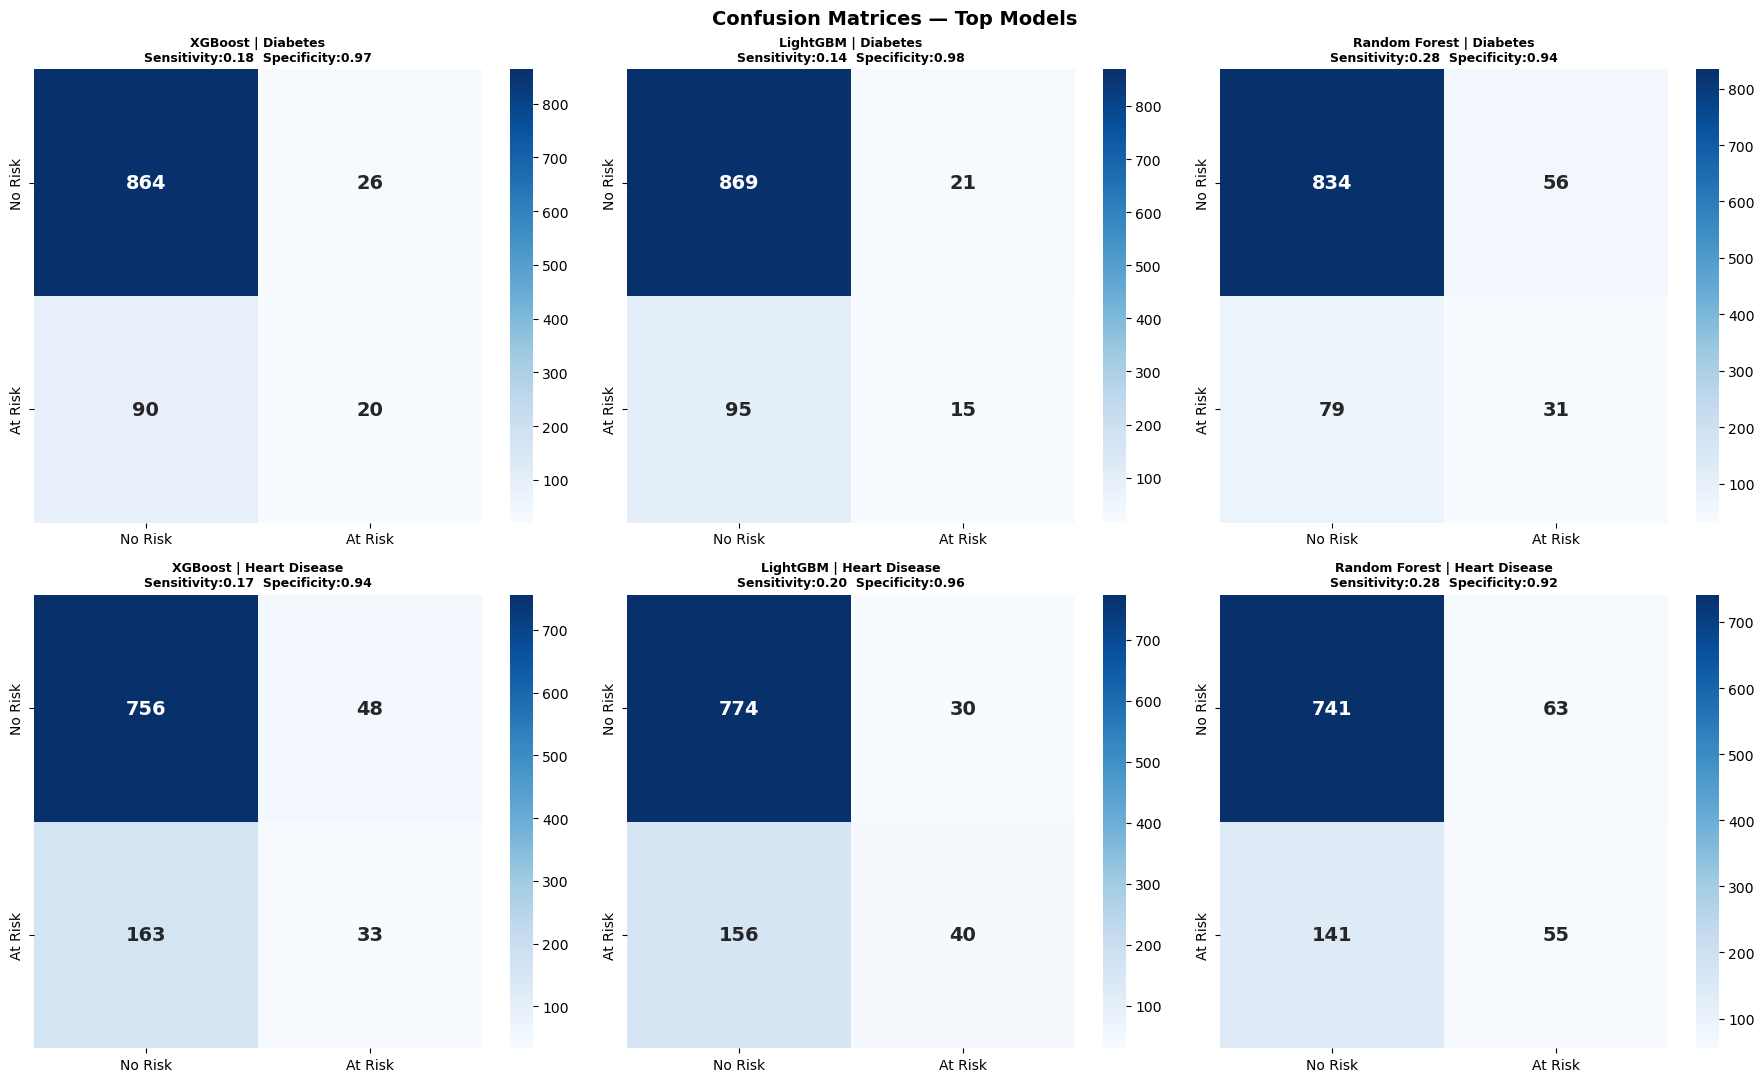

In [15]:
# ── Plot 6: Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(18,11))
fig.suptitle('Confusion Matrices — Top Models', fontsize=14, fontweight='bold')
for row, (models_d, y_te, disease) in enumerate([(d_models,yd_te,'Diabetes'),(h_models,yh_te,'Heart Disease')]):
    for col, nm in enumerate(['XGBoost','LightGBM','Random Forest']):
        if nm in models_d:
            yp = models_d[nm].predict(X_te_s)
            cm = confusion_matrix(y_te, yp)
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[row,col],
                        annot_kws={'size':14,'weight':'bold'},
                        xticklabels=['No Risk','At Risk'], yticklabels=['No Risk','At Risk'])
            tn,fp,fn,tp = cm.ravel()
            sens = tp/(tp+fn+1e-9); spec = tn/(tn+fp+1e-9)
            axes[row,col].set_title(f'{nm} | {disease}\nSensitivity:{sens:.2f}  Specificity:{spec:.2f}', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.savefig('/home/claude/plots/06_confusion_matrices.png', dpi=150, bbox_inches='tight'); 
plt.show()

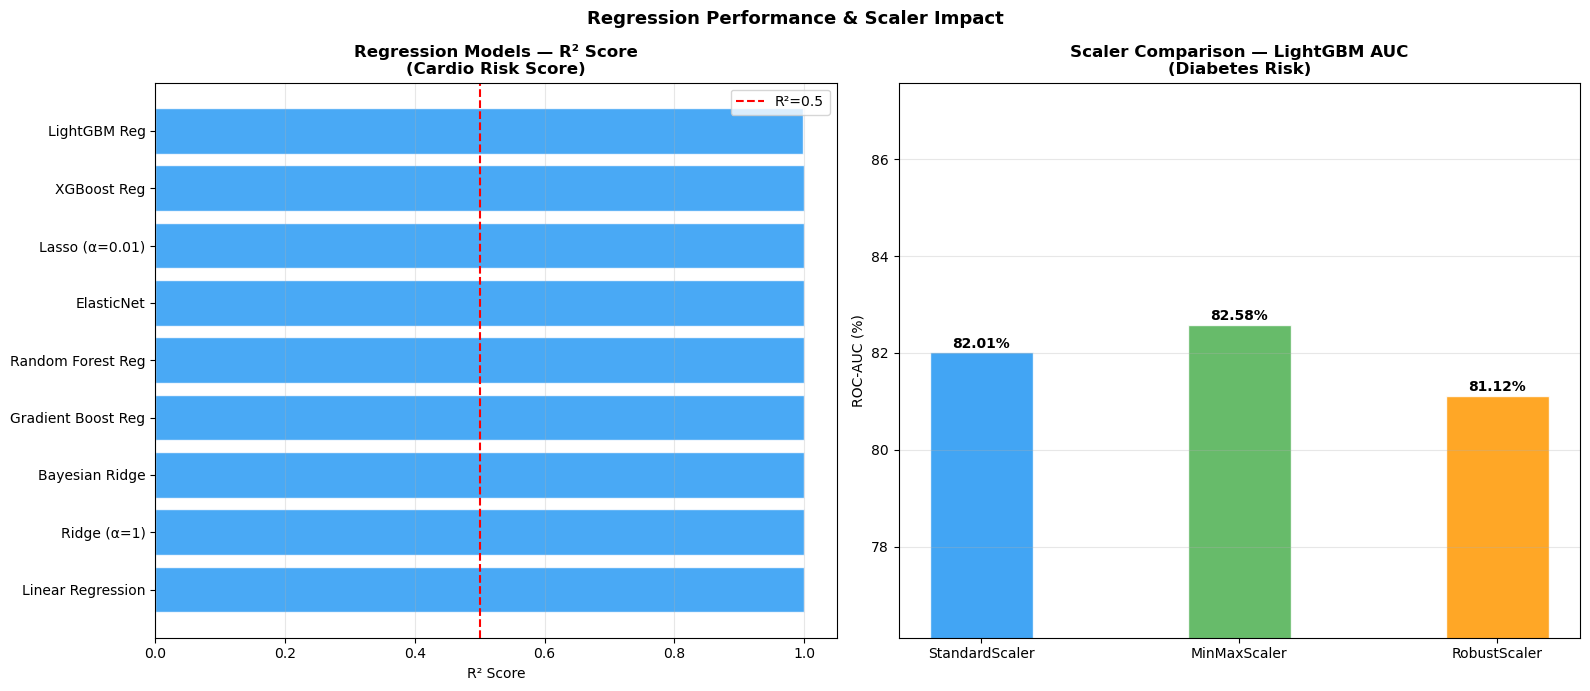

In [16]:
# ── Plot 7: Regression + Scaler ──────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(16,7))
fig.suptitle('Regression Performance & Scaler Impact', fontsize=13, fontweight='bold')
colors_r = ['#2196F3' if r>0 else '#FF5722' for r in df_reg['R2']]
axes[0].barh(df_reg['Model'], df_reg['R2'], color=colors_r, alpha=0.82, edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', lw=1.5, label='R²=0.5')
axes[0].set_title('Regression Models — R² Score\n(Cardio Risk Score)', fontweight='bold')
axes[0].set_xlabel('R² Score'); axes[0].legend(); axes[0].grid(axis='x', alpha=0.3)

sc_vals = list(scaler_res.values())
bars = axes[1].bar(list(scaler_res.keys()), sc_vals, color=['#2196F3','#4CAF50','#FF9800'], alpha=0.85, edgecolor='white', width=0.4)
for b,v in zip(bars,sc_vals): axes[1].text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f'{v}%', ha='center', fontweight='bold')
axes[1].set_title('Scaler Comparison — LightGBM AUC\n(Diabetes Risk)', fontweight='bold')
axes[1].set_ylabel('ROC-AUC (%)'); axes[1].set_ylim(min(sc_vals)-5, max(sc_vals)+5); axes[1].grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig('/home/claude/plots/07_regression_scaler.png', dpi=150, bbox_inches='tight'); 
plt.show()

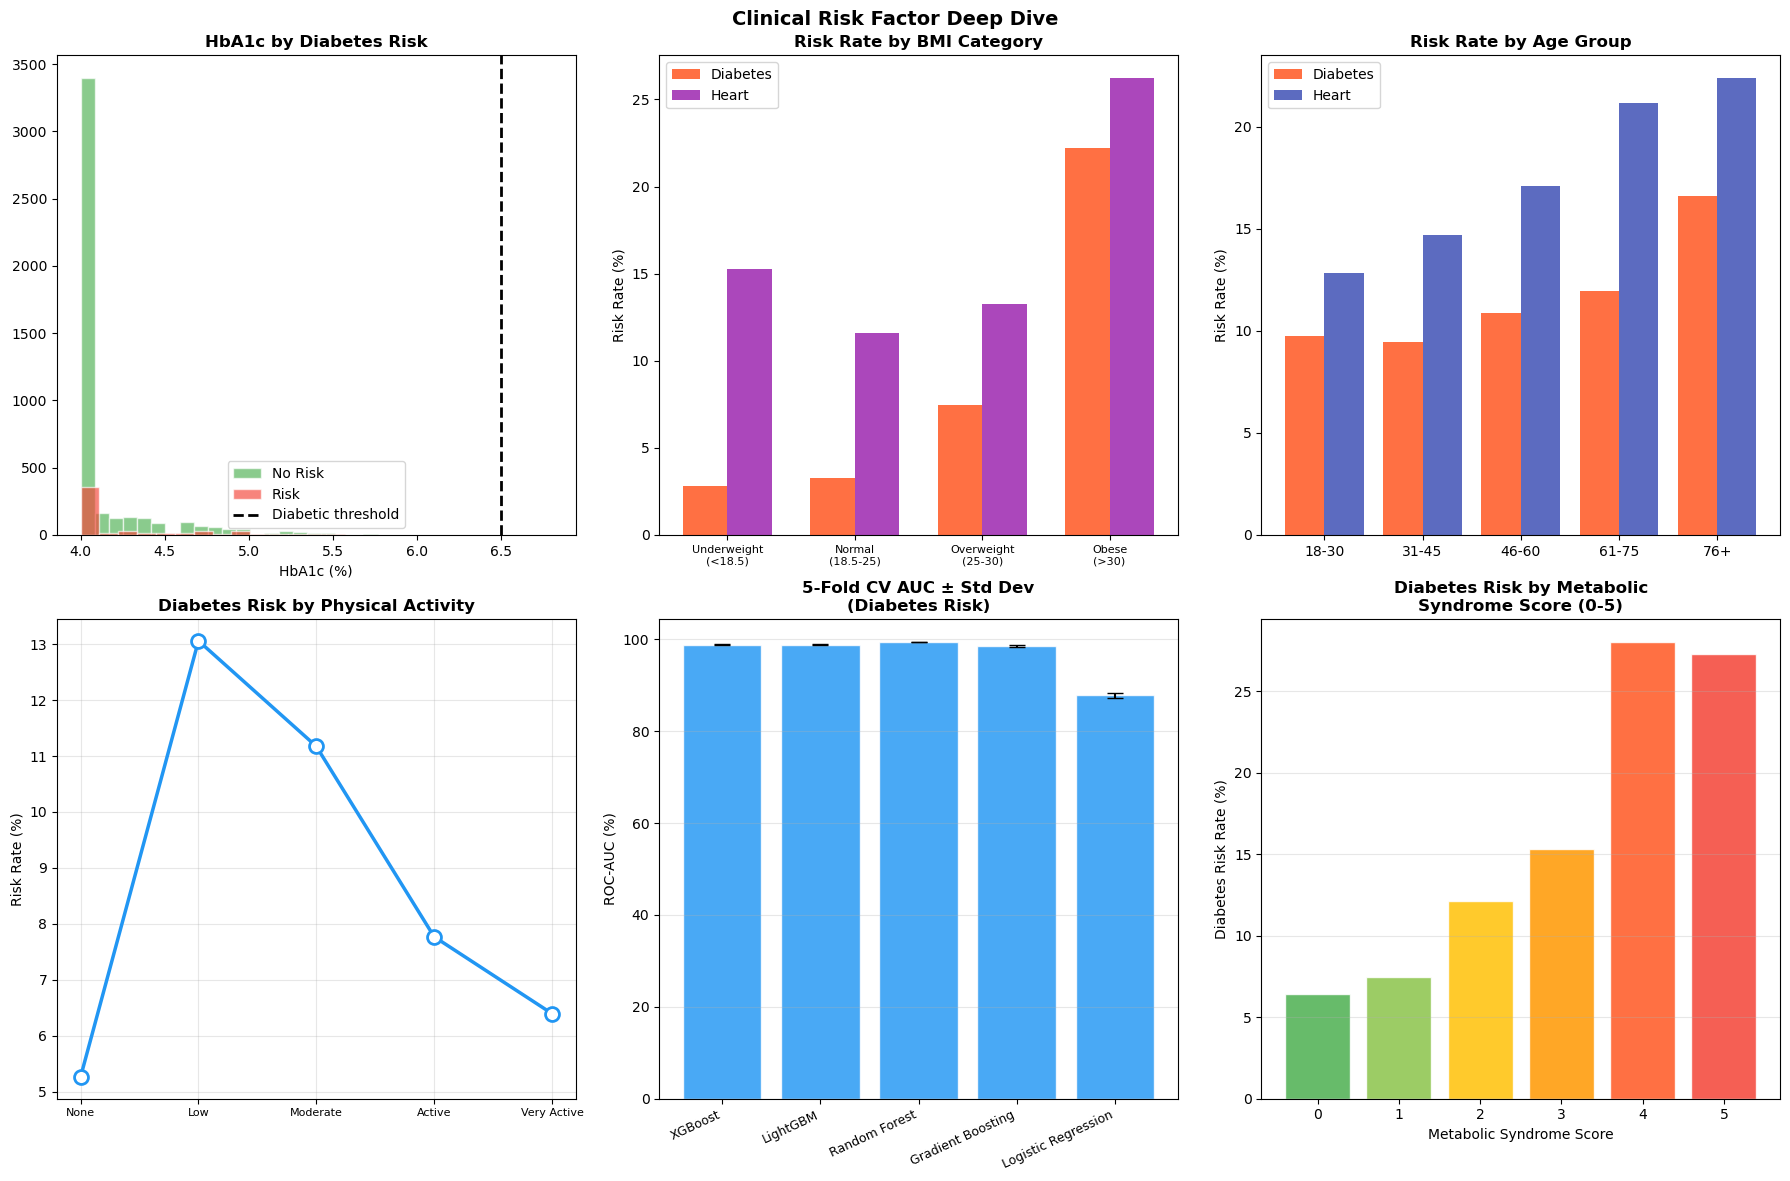

In [17]:
# ── Plot 8: Clinical Deep Dive ────────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(18,12))
fig.suptitle('Clinical Risk Factor Deep Dive', fontsize=14, fontweight='bold')

for v,lbl,c in [(0,'No Risk','#4CAF50'),(1,'Risk','#F44336')]:
    axes[0,0].hist(df[df['Diabetes_Risk']==v]['HbA1c_Pct'].dropna(), bins=25, alpha=0.65, color=c, label=lbl, edgecolor='white')
axes[0,0].axvline(6.5, color='black', linestyle='--', lw=2, label='Diabetic threshold')
axes[0,0].set_title('HbA1c by Diabetes Risk', fontweight='bold'); axes[0,0].set_xlabel('HbA1c (%)'); axes[0,0].legend()

bmi_cats = ['Underweight\n(<18.5)','Normal\n(18.5-25)','Overweight\n(25-30)','Obese\n(>30)']
df['BMI_Cat'] = pd.cut(df['BMI'], bins=[0,18.5,25,30,100], labels=bmi_cats)
dr = df.groupby('BMI_Cat',observed=False)['Diabetes_Risk'].mean()*100
hr = df.groupby('BMI_Cat',observed=False)['Heart_Disease_Risk'].mean()*100
x = np.arange(len(bmi_cats)); w = 0.35
axes[0,1].bar(x-w/2, dr.values, w, label='Diabetes', color='#FF5722', alpha=0.85)
axes[0,1].bar(x+w/2, hr.values, w, label='Heart', color='#9C27B0', alpha=0.85)
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(bmi_cats, fontsize=8)
axes[0,1].set_title('Risk Rate by BMI Category', fontweight='bold'); axes[0,1].set_ylabel('Risk Rate (%)'); axes[0,1].legend()

df['Age_Group'] = pd.cut(df['Age'], bins=[17,30,45,60,75,100], labels=['18-30','31-45','46-60','61-75','76+'])
ad = df.groupby('Age_Group',observed=False)['Diabetes_Risk'].mean()*100
ah = df.groupby('Age_Group',observed=False)['Heart_Disease_Risk'].mean()*100
x = np.arange(len(ad))
axes[0,2].bar(x-0.2, ad.values, 0.4, label='Diabetes', color='#FF5722', alpha=0.85)
axes[0,2].bar(x+0.2, ah.values, 0.4, label='Heart', color='#3F51B5', alpha=0.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(ad.index)
axes[0,2].set_title('Risk Rate by Age Group', fontweight='bold'); axes[0,2].set_ylabel('Risk Rate (%)'); axes[0,2].legend()

df['PA_Cat'] = pd.cut(df['Physical_Activity_Min_Week'], bins=[-1,0,75,150,300,10000], labels=['None','Low','Moderate','Active','Very Active'])
pa_r = df.groupby('PA_Cat',observed=False)['Diabetes_Risk'].mean()*100
axes[1,0].plot(range(len(pa_r)), pa_r.values, 'o-', color='#2196F3', lw=2.5, ms=10, mfc='white', mew=2)
axes[1,0].set_xticks(range(len(pa_r))); axes[1,0].set_xticklabels(pa_r.index, fontsize=8)
axes[1,0].set_title('Diabetes Risk by Physical Activity', fontweight='bold'); axes[1,0].set_ylabel('Risk Rate (%)'); axes[1,0].grid(alpha=0.3)

cv_names = list(cv_res.keys()); cv_means = [cv_res[n]['mean'] for n in cv_names]; cv_stds = [cv_res[n]['std'] for n in cv_names]
axes[1,1].bar(range(len(cv_names)), cv_means, yerr=cv_stds, capsize=6, color='#2196F3', alpha=0.82, edgecolor='white')
axes[1,1].set_xticks(range(len(cv_names))); axes[1,1].set_xticklabels(cv_names, rotation=25, ha='right', fontsize=9)
axes[1,1].set_title('5-Fold CV AUC ± Std Dev\n(Diabetes Risk)', fontweight='bold'); axes[1,1].set_ylabel('ROC-AUC (%)'); axes[1,1].grid(axis='y',alpha=0.3)

ms_r = df.groupby('Metabolic_Syndrome_Score')['Diabetes_Risk'].mean()*100
axes[1,2].bar(ms_r.index.astype(str), ms_r.values, color=['#4CAF50','#8BC34A','#FFC107','#FF9800','#FF5722','#F44336'], alpha=0.85, edgecolor='white')
axes[1,2].set_title('Diabetes Risk by Metabolic\nSyndrome Score (0-5)', fontweight='bold')
axes[1,2].set_xlabel('Metabolic Syndrome Score'); axes[1,2].set_ylabel('Diabetes Risk Rate (%)'); axes[1,2].grid(axis='y',alpha=0.3)

plt.tight_layout(); plt.savefig('/home/claude/plots/08_clinical_analysis.png', dpi=150, bbox_inches='tight'); 
plt.show()


In [18]:
print("   All 8 plots saved ✓")

   All 8 plots saved ✓


In [19]:
# Save CSVs
df_d.to_csv('/home/claude/diabetes_model_results.csv', index=False)
df_h.to_csv('/home/claude/heart_model_results.csv', index=False)
df_reg.to_csv('/home/claude/regression_results.csv', index=False)

# Summary
print("\n" + "="*70)
print("PIPELINE SUMMARY")
print(f"  Dataset: 5,000 patients × {df.shape[1]} features")
print(f"  Diabetes Classification models: {len(d_results)}")
print(f"  Heart Disease Classification models: {len(h_results)}")
print(f"  Regression models: {len(reg_results)}")
print(f"  Best Diabetes AUC: {df_d['ROC_AUC'].max()}% ({df_d.iloc[0]['Model']})")
print(f"  Best Heart AUC: {df_h['ROC_AUC'].max()}% ({df_h.iloc[0]['Model']})")
print(f"  Best Regression R²: {df_reg['R2'].max()} ({df_reg.iloc[0]['Model']})")
print(f"  Tuned XGBoost AUC: {tuned_auc:.2f}%")
print(f"  Ensemble Voting AUC: {ens_auc:.2f}%")
print(f"  Scaler Comparison: {scaler_res}")
print("="*70)

# Save key stats for report
stats = {
    'diabetes_best_model': df_d.iloc[0]['Model'],
    'diabetes_best_auc': df_d['ROC_AUC'].max(),
    'heart_best_model': df_h.iloc[0]['Model'],
    'heart_best_auc': df_h['ROC_AUC'].max(),
    'tuned_xgb_auc': round(tuned_auc,2),
    'ensemble_auc': round(ens_auc,2),
    'ensemble_f1': round(ens_f1,2),
    'scaler_res': scaler_res,
    'top_features_xgb': fi_xgb['Feature'].head(10).tolist(),
    'top_features_rf': fi_rf['Feature'].head(10).tolist(),
    'best_regression': df_reg.iloc[0]['Model'],
    'best_r2': df_reg['R2'].max(),
    'cv_res': cv_res,
    'best_params': xgb_gs.best_params_,
    'df_d': df_d.to_dict('records'),
    'df_h': df_h.to_dict('records'),
    'df_reg': df_reg.to_dict('records'),
}
with open('/home/claude/stats.json','w') as f:
    json.dump(stats, f, indent=2)


PIPELINE SUMMARY
  Dataset: 5,000 patients × 93 features
  Diabetes Classification models: 15
  Heart Disease Classification models: 15
  Regression models: 9
  Best Diabetes AUC: 83.54% (Logistic Regression)
  Best Heart AUC: 79.52% (AdaBoost)
  Best Regression R²: 1.0 (Linear Regression)
  Tuned XGBoost AUC: 81.91%
  Ensemble Voting AUC: 82.38%
  Scaler Comparison: {'StandardScaler': np.float64(82.01), 'MinMaxScaler': np.float64(82.58), 'RobustScaler': np.float64(81.12)}
